# Platinum hedge — validation notebook

**Purpose: prove the differential-ML hedging stack works.** This notebook is a regression
harness for a quant seeing the stack fresh. It runs the public JSON-in / result-out contract
(`cx = rf.Context(); cx.load_json(...); cx.run_job()`) and checks a series of asserts — two of
which are *bitwise* regression anchors. Every section appends a pass/fail row to `CHECKS`;
the final cell prints the green/red scorecard.

The deal is a 3-month average-price platinum swap (the dealer is short the LBMA fixing) hedged
with a strip of CME futures. The solver is `DiffSolverV2` under an `AsymmetricUtility_Huber`
objective. Everything here obeys *JSON-is-the-contract*: config edits happen on loaded dicts,
the fixture / shipping JSON on disk are never mutated, and no `riskflow` internals are imported.

## 1. Setup + environment check

Pin GPU 0 (GPU 1 is busy), import the public surface, and — critically — assert we imported the *repo* `riskflow`, not the reference-snapshot shadow copy that `import riskflow` silently resolves to when the repo root is not first on `sys.path`.

In [1]:
import os
# Pin to GPU0 BEFORE torch initialises CUDA (GPU1 is busy; the bitwise anchors below were
# calibrated on this device). Must run before riskflow/torch import CUDA.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import riskflow as rf

# The shadow-import trap is real: import riskflow resolves to an old snapshot unless the repo
# root is on sys.path. Fail loud if we grabbed the wrong tree.
assert 'PycharmProjects' in rf.__file__, f"shadow-import trap — got {rf.__file__}"
print('riskflow  :', rf.__file__)
print('torch     :', torch.__version__, '| CUDA', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device    :', torch.cuda.get_device_name(0))

CHECKS = []  # (name, passed) rows for the final scorecard
def record(name, ok):
    CHECKS.append((name, bool(ok)))
    print(('PASS' if ok else 'FAIL'), '-', name)
    return ok

riskflow  : /home/vretiel/PycharmProjects/riskflow/riskflow/__init__.py
torch     : 2.8.0+cu128 | CUDA True
device    : NVIDIA GeForce RTX 3090


## 2. The shipping config

`artifacts/platinum_hedge_shipping.json` is the validated production deliverable: the corrected
composed-spot platinum world (CME primary `P` is the martingale, `CommodityBasis.LME_CME` carries
the published basis `b = S − P`, and the LBMA fixing `S = P + b` is priced from them). Below we
read the deal economics straight off the loaded dict — the liability leg, the CME futures strip,
the utility objective, and the position limits.

In [2]:
SHIP_PATH = 'artifacts/platinum_hedge_shipping.json'
ship = json.load(open(SHIP_PATH))
hp = ship['Calc']['Calculation']['Hedging_Problem']

# --- liability leg ---
liab_name, liab = next(iter(hp['Liabilities']['FloatingEnergyDeal'].items()))
item = liab['Payments']['Items'][0]
liab_tbl = pd.DataFrame([{
    'deal': liab_name,
    'commodity': liab['Commodity'],
    'volume_oz': item['Volume'],
    'avg_start': item['Period_Start']['.Timestamp'],
    'avg_end': item['Period_End']['.Timestamp'],
    'pay_date': item['Payment_Date']['.Timestamp'],
    'strike_$/oz': round(-item['Fixed_Basis'], 2),   # Fixed_Basis = -strike
}])
print('LIABILITY (dealer receives fixed, pays the floating average):')
display(liab_tbl)

# --- CME futures strip (the hedges) ---
futs = hp['Tradable_Instruments']['CommodityFutureDeal']
lims = hp['Evaluator']['Position_Limits']
hedge_tbl = pd.DataFrame([{
    'hedge': n,
    'maturity': f['Maturity_Date']['.Timestamp'],
    'implied_basis': f['Implied_Basis'],
    'contract_size': f['Contract_Size'],
    'settle_price': hp['Portfolio_State']['Settlement_Prices'][n],
    'min_pos': lims[n]['Min_Position'],
    'max_pos': lims[n]['Max_Position'],
} for n, f in futs.items()])
print('HEDGES (short-only CME strip, referencing P via the CME_FLAT identity basis):')
display(hedge_tbl)

# --- objective ---
obj = hp['Objective']
print('OBJECTIVE:', obj['Object'], '| Huber_Aversion =', obj['Huber_Aversion'],
      '| Huber_Delta =', obj['Huber_Delta'])
print('Total position abs limit:', hp['Evaluator']['Total_Position_Abs_Limit'])

LIABILITY (dealer receives fixed, pays the floating average):


,deal,commodity,volume_oz,avg_start,avg_end,pay_date,strike_$/oz
0,PLAT_JUL29,PLATINUM_LME,2500.0,2026-03-01,2026-03-31,2026-04-05,1696.5


HEDGES (short-only CME strip, referencing P via the CME_FLAT identity basis):


,hedge,maturity,implied_basis,contract_size,settle_price,min_pos,max_pos
0,PL_M1,2026-01-30,CME_FLAT,50,1666.7819,-50,0
1,PL_M2,2026-04-30,CME_FLAT,50,1674.7606,-50,0
2,PL_M3,2026-07-31,CME_FLAT,50,1673.2864,-50,0


OBJECTIVE: AsymmetricUtility_Huber | Huber_Aversion = 6.0 | Huber_Delta = 1.0
Total position abs limit: 50


## 3. Bit-gate regression (anchor #1)

A *bitwise* gate on the headline value `V_0`. This is the strongest regression guard the stack
has: it runs the full backward DP on the canonical fixture at a fixed small fidelity (Batch 256,
Inner 32, antithetic on, seed 7, 5 grid levels, 5 fit iters, full decision window `T_Min=0`) and
demands `V_0` reproduce to the last bit. Any accidental change to the sim, the pricing, the inner
MC, the utility scale, or the solver's arithmetic shifts a low bit and trips this — a coarse
tolerance would hide exactly those regressions. (The anchor is device-specific: it was calibrated
on the GPU pinned in section 1.)

In [3]:
V0_ANCHOR = 0.06715935468673706

cfg = json.load(open('tests/fixtures/policy_test_simulate_only.json'))  # on-disk fixture NEVER edited
calc = cfg['Calc']['Calculation']                                       # edits live on the loaded dict
calc['Execution_Mode'] = 'solve_hedge'
calc['Batch_Size'] = 256
calc['Inner_Sub_Batch'] = 32
calc['Inner_MC_Enabled'] = 'Yes'
calc['Inner_Antithetic'] = 'Yes'
calc['Random_Seed'] = 7
calc['Hedging_Problem']['Randomize_Initial_State'] = 'Yes'
calc['Hedging_Problem']['Solver'] = {
    'Object': 'DiffSolverV2',
    'Training_Action_Grid_Levels_Per_Axis': 5,
    'Training_Action_Chunk_Size': 64,
    'T_Min': 0,                    # full decision window (day-1 policy)
    'DiffV2_Fit_Iters': 5,
    'DiffV2_OOS_Frac': 0.5,
}

cx = rf.Context()
cx.load_json((json.dumps(cfg), 'bitgate.json'))
_, result = cx.run_job()
diag = (result.evaluation_summary or {}).get('diagnostics') or {}
V0 = float(diag['V_0'])
print(f'V_0          = {V0!r}')
print(f'anchor       = {V0_ANCHOR!r}')
print(f'abs diff     = {abs(V0 - V0_ANCHOR):.3e}')
ok = abs(V0 - V0_ANCHOR) < 1e-15
record('bit-gate: V_0 reproduces to 1e-15', ok)
assert ok, f'V_0 drifted: {V0!r} vs anchor {V0_ANCHOR!r}'

V_0          = 0.06715935468673706
anchor       = 0.06715935468673706
abs diff     = 0.000e+00
PASS - bit-gate: V_0 reproduces to 1e-15


## 4. Small real solve on the shipping config

Now solve the actual shipping deal (batch 256, only 5 fit iters so it stays a smoke) with the
hindsight upper-bound and textbook lower-bound benchmarks switched on. The **acceptance ladder**
must hold *on the frictionless objective*: hindsight ≥ DiffSolverV2 (greedy) ≥ textbook. We also
show the net-of-cost columns (turnover charged at the shared kappa) and confirm the solver returns
a JSON-serialisable `policy_artifact` carrying the value-function state plus a `solver_version` and
`config_hash`.

In [4]:
cfg = json.load(open(SHIP_PATH))
calc = cfg['Calc']['Calculation']
calc['Batch_Size'] = 256
solver = calc['Hedging_Problem']['Solver']
solver['DiffV2_Fit_Iters'] = 5                       # smoke fidelity
solver['Run_Hindsight_Diagnostic'] = 'Yes'          # upper bound track
solver['Run_Textbook_Benchmark'] = 'Yes'            # lower bound track

cx = rf.Context()
cx.load_json((json.dumps(cfg, default=str), 'ship_smoke.json'))
_, result = cx.run_job()
es = result.evaluation_summary

In [5]:
# --- acceptance ladder (frictionless V_0 per track) ---
ladder = es['ladder']
ladder_tbl = pd.DataFrame(ladder['order'], columns=['track', 'V_0 (frictionless)'])
print('ACCEPTANCE LADDER  (must be monotone decreasing):')
display(ladder_tbl)
ok_ladder = bool(ladder['holds'])
record('ladder: hindsight >= greedy >= textbook', ok_ladder)
assert ok_ladder, f'ladder violated: {ladder}'

ACCEPTANCE LADDER  (must be monotone decreasing):


,track,V_0 (frictionless)
0,hindsight,2.326296
1,DiffSolverV2,-0.561196
2,textbook,-0.666039


PASS - ladder: hindsight >= greedy >= textbook


In [6]:
# --- net-of-cost columns (where each track reports them) ---
comp = es['comparison']
greedy = es['diagnostics']['verdict']['greedy']
rows = []
for track in ('HindsightDpSolver', 'DiffSolverV2', 'textbook'):
    c = comp.get(track, {})
    if track == 'DiffSolverV2':      # greedy's net-of-cost lives in the OOS verdict
        net, cost = greedy.get('u_mean_net'), greedy.get('turnover_cost_mean')
    else:
        net, cost = c.get('v0_mean_net'), c.get('turnover_cost_mean')
    rows.append({'track': track, 'V_0_gross': round(c.get('v0_mean'), 4),
                 'V_0_net': None if net is None else round(net, 4),
                 'turnover_cost_$': None if cost is None else round(cost, 1),
                 'n_star': c.get('n_star')})
print('NET-OF-COST DIAGNOSTICS:')
display(pd.DataFrame(rows))

NET-OF-COST DIAGNOSTICS:


,track,V_0_gross,V_0_net,turnover_cost_$,n_star
0,HindsightDpSolver,2.3263,NaN,NaN,"[-8.3984375, -16.015625, -1.953125]"
1,DiffSolverV2,-0.5612,-0.4973,14969.5,"[-0.146484375, -25.830078125, 0.0]"
2,textbook,-0.6660,-0.6771,4311.7,"[-18.75, -31.25, 0.0]"


In [7]:
# --- policy artifact contract ---
art = result.policy_artifact
print('policy_artifact keys :', sorted(art.keys()))
print('solver_version       :', art['solver_version'])
print('config_hash          :', art['config_hash'])
print('V_0 (in artifact)    :', art['V_0'])
ok_art = isinstance(art, dict) and bool(art['solver_version']) and isinstance(art['config_hash'], str)
record('artifact: carries solver_version + config_hash', ok_art)
assert ok_art

policy_artifact keys : ['T_dec', 'V_0', 'a_bounds', 'active_hedge_indices', 'config_hash', 'hedges', 'hidden', 'm_mean', 'm_std', 'max_abs_Y_boot', 'md', 'n_star_0', 'solver_version', 'state_dicts', 't_min', 'utility_scale', 'w_mean', 'w_std']
solver_version       : diffsolverv2/2026-07
config_hash          : 63a676225fc8736804155d1263b058760eeb36a3
V_0 (in artifact)    : -0.5611962080001831
PASS - artifact: carries solver_version + config_hash


## 5. Martingale guard (the basis-harvest lesson)

**Why this guard exists.** An earlier version put the stochastic basis on the *tradeable* leg.
That gave the hedges a non-zero `E[dF]` — the solver learned to harvest the basis's mean reversion,
a P&L that *cannot actually be executed* (you can't trade the LBMA fixing). The fix inverts the
world: the CME leg `P` is the martingale primary, and the catch-up lives entirely in the (untradeable)
LBMA leg `S = P + b`. So on the *simulated* paths the guard must show:

* `dP ~ b` — slope ≈ 0, **|t| small** (each future references `P`, a martingale w.r.t. the basis;
  nothing to harvest), and
* `dS ~ b` — **t strongly negative** (the mean-reverting catch-up loads on the untradeable leg).

We pull the simulated factor paths straight off `result.bundle['factors']` (a fresh `simulate_only`
run) and regress in plain numpy.

In [8]:
cfg = json.load(open(SHIP_PATH))
calc = cfg['Calc']['Calculation']
calc['Execution_Mode'] = 'simulate_only'
calc['Batch_Size'] = 512
calc['Random_Seed'] = 7
cx = rf.Context()
cx.load_json((json.dumps(cfg, default=str), 'martingale_sim.json'))
_, sim = cx.run_job()

F = sim.bundle['factors']                                   # simulated (T, B) factor paths
P = F['CommodityPrice.PLATINUM_CME'].detach().cpu().numpy()  # martingale primary
S = F['CommodityPrice.PLATINUM_LME'].detach().cpu().numpy()  # LBMA fixing = P + b
b = F['CommodityBasis.LME_CME'].detach().cpu().numpy()       # published basis b = S - P
assert np.max(np.abs(S - (P + b))) == 0.0                    # composition is exact

def ols_slope_t(y, x):
    m = np.isfinite(y) & np.isfinite(x)
    y, x = y[m], x[m]
    X = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    se = np.sqrt((resid ** 2).sum() / (len(x) - 2) / ((x - x.mean()) ** 2).sum())
    return float(coef[1]), float(coef[1] / se)

x = b[:-1].ravel()                        # basis b(t), pooled over t and paths
sP, tP = ols_slope_t((P[1:] - P[:-1]).ravel(), x)   # dP(t+1) ~ b(t)
sS, tS = ols_slope_t((S[1:] - S[:-1]).ravel(), x)   # dS(t+1) ~ b(t)
guard_tbl = pd.DataFrame([
    {'regression': 'dP ~ b  (tradeable, martingale)', 'slope': round(sP, 5), 't_stat': round(tP, 2),
     'pass_if': '|t| small'},
    {'regression': 'dS ~ b  (untradeable catch-up)', 'slope': round(sS, 5), 't_stat': round(tS, 2),
     'pass_if': 't << 0'},
])
display(guard_tbl)
ok_mart = (abs(tP) < 3.0) and (tS < -20.0)
record('martingale guard: E[dP|b]~0, dS~b strongly negative', ok_mart)
assert ok_mart, f'guard failed: t_dP={tP:.2f} t_dS={tS:.2f}'

,regression,slope,t_stat,pass_if
0,"dP ~ b (tradeable, martingale)",0.00363,0.85,|t| small
1,dS ~ b (untradeable catch-up),-0.51244,-215.85,t << 0


PASS - martingale guard: E[dP|b]~0, dS~b strongly negative


## 6. Stepper demo (anchor #2)

The `result.create_stepper()` surface drives the simulator one day at a time under *futures*
accounting. Here we run a deterministic **−3-lot policy**: hold a constant short of 3 `PL_JUL_2026`
contracts for the life of the deal. We plot the terminal-wealth distribution across paths and one
sample simulated futures mark, then bitwise-assert the terminal net wealth of the first five paths
(anchor #2). Under futures accounting with force-flat-at-end the excess P&L books at settlement, so
`W` here is *terminal* net wealth per path.

In [9]:
FIX = 'tests/fixtures/policy_test_simulate_only.json'
HEDGE, TARGET = 'PL_JUL_2026', -3
W_ANCHOR = [88946.703125, 1676837.25, -430734.625, -828350.0, -174269.625]  # first 5 paths' terminal W

cfg = json.load(open(FIX))
calc = cfg['Calc']['Calculation']
calc['Execution_Mode'] = 'simulate_only'
calc['Batch_Size'] = 256
calc['Random_Seed'] = 7
cx = rf.Context()
cx.load_json((json.dumps(cfg), 'stepper_demo.json'))
_, sim = cx.run_job()

stepper = sim.create_stepper()
mark0 = []                       # PL_JUL_2026 mark for path 0, every step (the sample path)
last = None
while not stepper.done:
    tv = stepper.observe()['tradable_values'].get(HEDGE)
    if tv is not None:
        mark0.append(float(tv[0].item()))
    if stepper.is_decision_step:
        cur = float(stepper.observe()['positions'][HEDGE][0].item())
        last = stepper.step({HEDGE: TARGET - int(round(cur))})   # trade to the -3 target
    else:
        last = stepper.step(None)

W = (last['transition_pnl_excess'] + last['transition_liability_value']).to(dtype=torch.float64).cpu().numpy()
print('terminal net wealth: mean=${:,.0f}  min=${:,.0f}  max=${:,.0f}'.format(W.mean(), W.min(), W.max()))
print('W[0..4]  =', [float(w) for w in W[:5]])
print('anchor   =', W_ANCHOR)
ok_step = np.array_equal(W[:5].astype(float), np.array(W_ANCHOR))
record('stepper: -3-lot terminal W[0..4] reproduces bitwise', ok_step)
assert ok_step, f'stepper anchor drifted: {list(W[:5])}'

terminal net wealth: mean=$41,802  min=$-1,494,885  max=$3,618,889
W[0..4]  = [88946.703125, 1676837.25, -430734.625, -828350.0, -174269.625]
anchor   = [88946.703125, 1676837.25, -430734.625, -828350.0, -174269.625]
PASS - stepper: -3-lot terminal W[0..4] reproduces bitwise


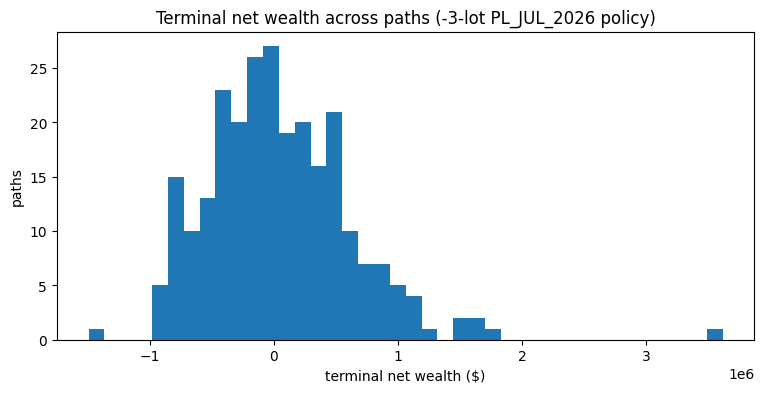

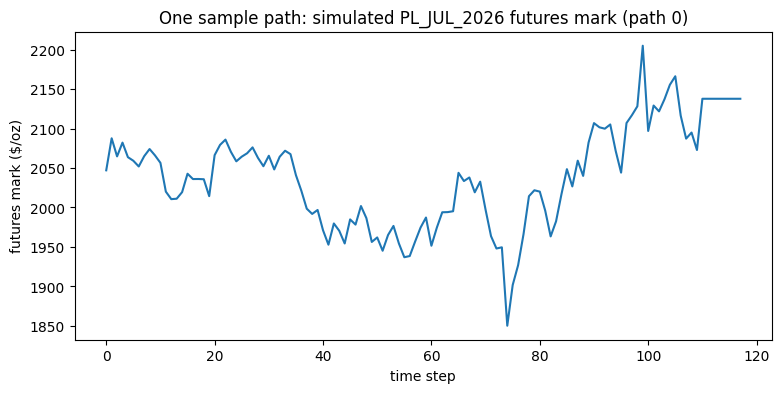

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(W, bins=40)
ax.set_title('Terminal net wealth across paths (-3-lot PL_JUL_2026 policy)')
ax.set_xlabel('terminal net wealth ($)')
ax.set_ylabel('paths')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mark0)
ax.set_title('One sample path: simulated PL_JUL_2026 futures mark (path 0)')
ax.set_xlabel('time step')
ax.set_ylabel('futures mark ($/oz)')
plt.show()

## 7. Summary scorecard

Green/red checklist of every assert in this notebook.

In [11]:
print('=' * 52)
print('VALIDATION SCORECARD')
print('=' * 52)
for name, ok in CHECKS:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
print('=' * 52)
n_pass = sum(ok for _, ok in CHECKS)
print(f'{n_pass}/{len(CHECKS)} checks passed')
assert all(ok for _, ok in CHECKS), 'one or more validation checks FAILED'
print('ALL GREEN')

VALIDATION SCORECARD
  [PASS]  bit-gate: V_0 reproduces to 1e-15
  [PASS]  ladder: hindsight >= greedy >= textbook
  [PASS]  artifact: carries solver_version + config_hash
  [PASS]  martingale guard: E[dP|b]~0, dS~b strongly negative
  [PASS]  stepper: -3-lot terminal W[0..4] reproduces bitwise
5/5 checks passed
ALL GREEN
